In [7]:
from src.Data_utils import load_from_sql
import matplotlib.pyplot as plt
import seaborn as sns

data=load_from_sql("HOUSEPRICE")
print(data.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [9]:
##Descriptive statistics

data.describe()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


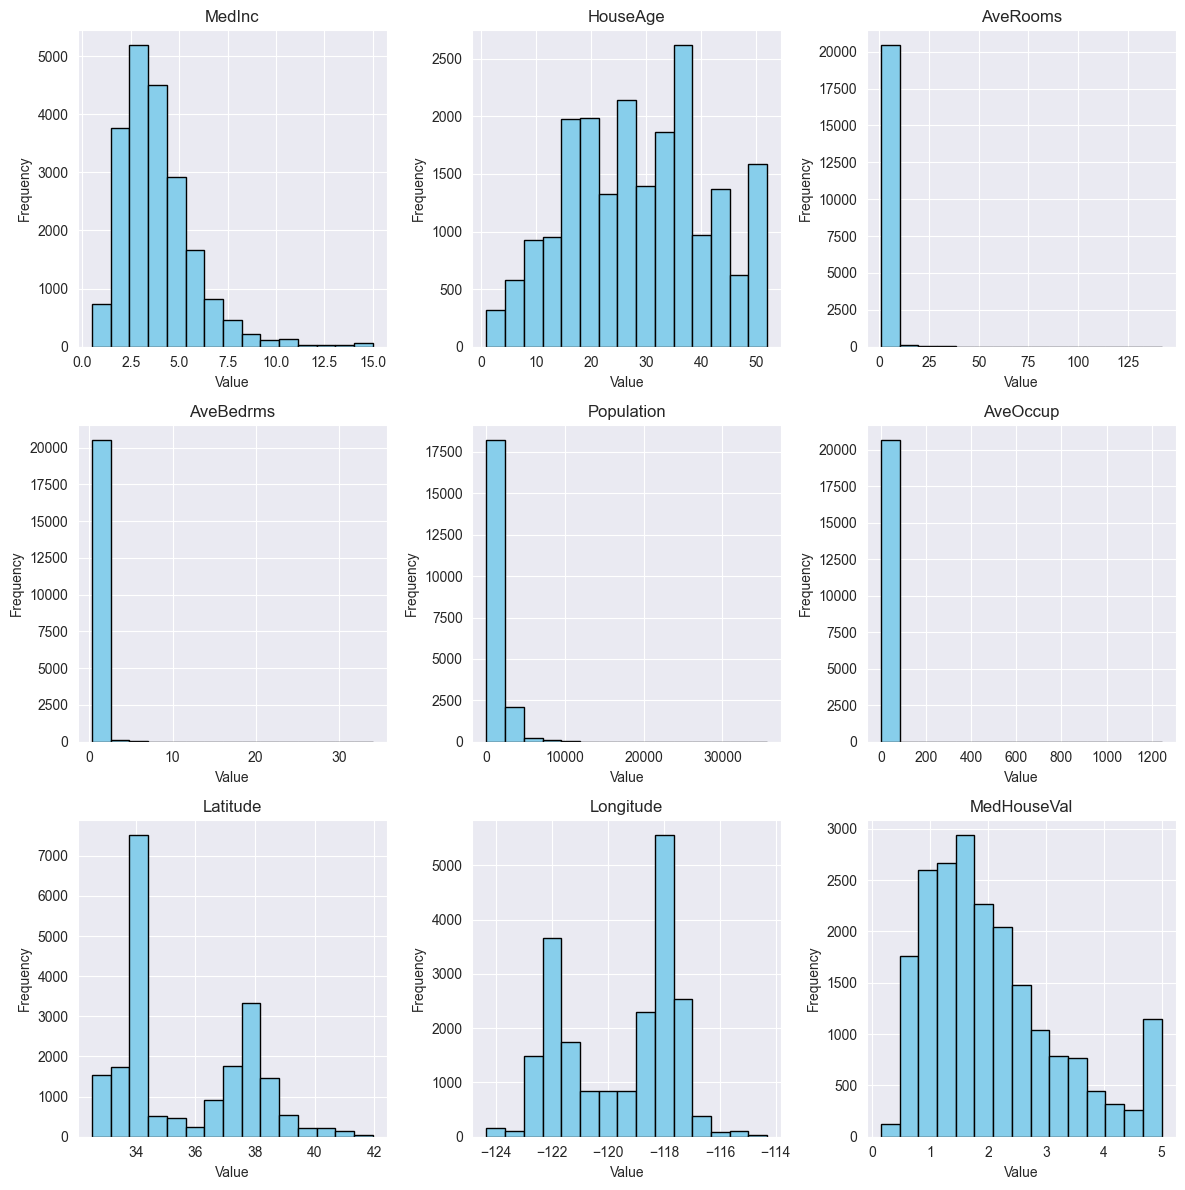

In [10]:
##First lets inspect probability density function to find any skewness within data

cols=data.columns

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12, 12))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    ax.hist(data[col], bins=15, color='skyblue', edgecolor='black')
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

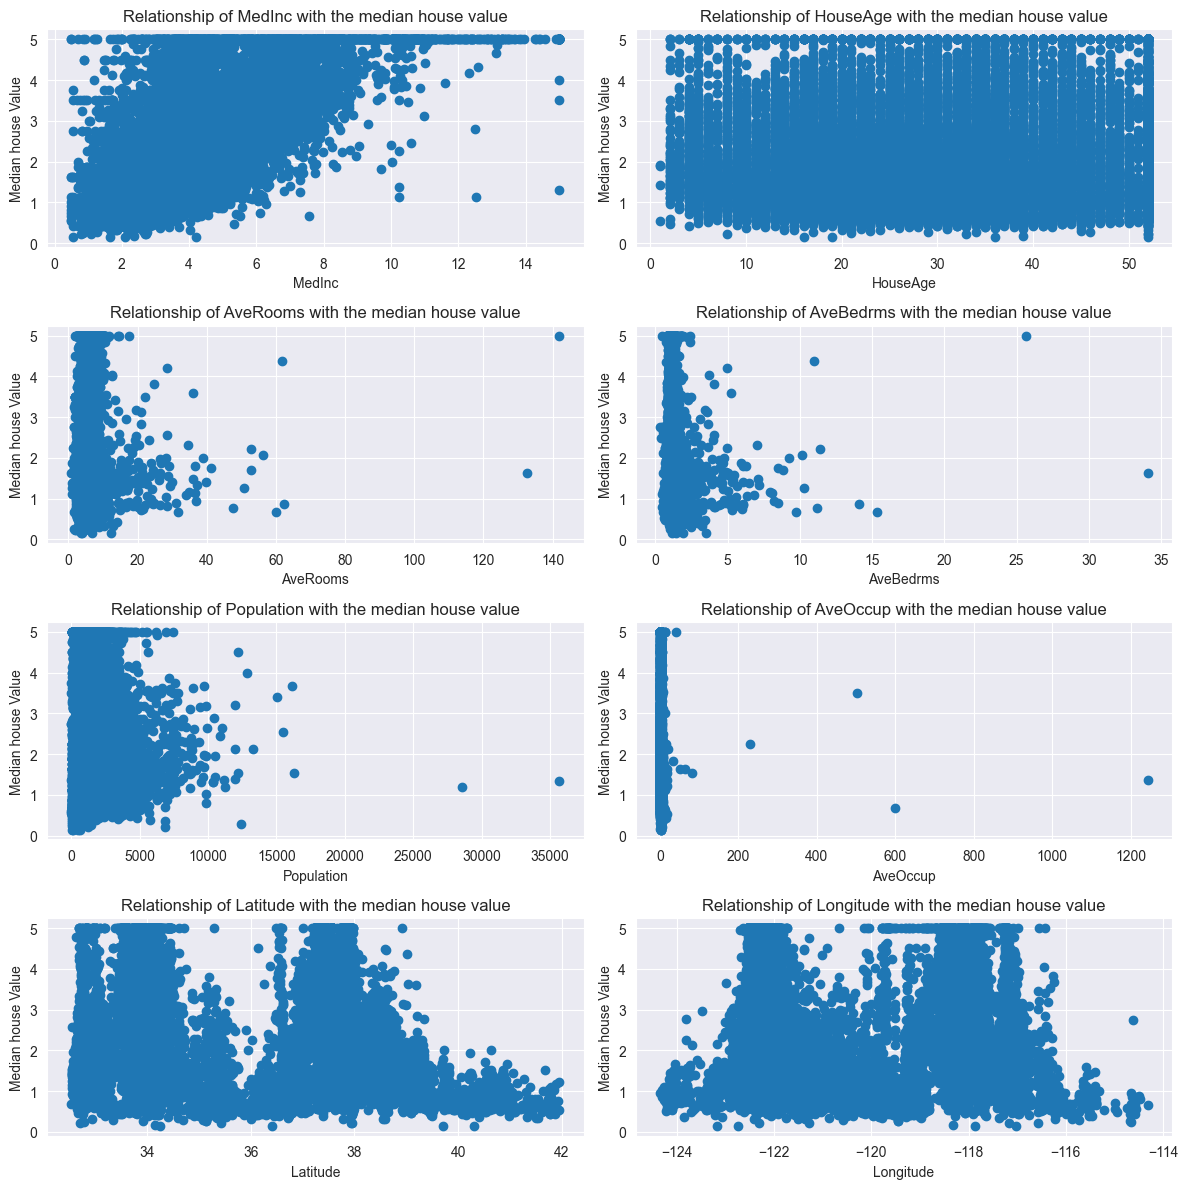

In [13]:
##Relationship with the outcome variable

fig , axes=plt.subplots(nrows=4, ncols=2, figsize=(12, 12))
axes=axes.flatten()

for ax, col in zip(axes, cols[:-1]):
    ax.scatter(data[col], data["MedHouseVal"])
    ax.set_title(f"Relationship of {col} with the median house value")
    ax.set_xlabel(col)
    ax.set_ylabel('Median house Value')

plt.tight_layout()
plt.show()

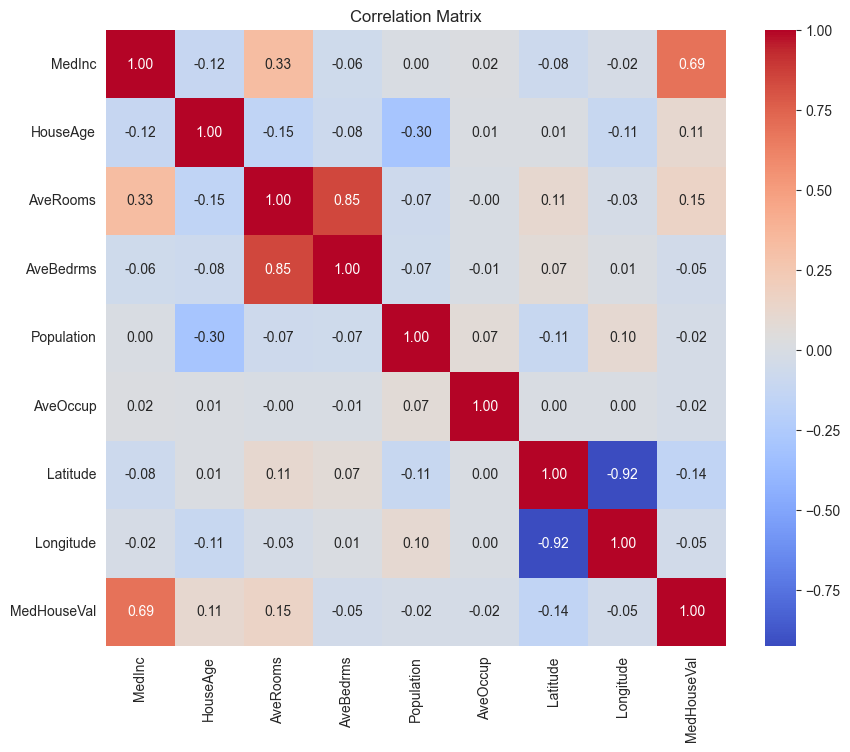

In [12]:
##Correlation matrix

corr = data.corr()

# plot heatmap with gradient
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix")
plt.show()


* Median house value is right skewed suggesting log transformation is needed.
* Relationships are highly non-linear meaning linear regression is not a good model fit
* Average bedroom and average room and average occupation variables have very low variance
* Median income is by far the strongest factor influencing the dependent variable. Furthermore, house age could be a useful variable